<table style="background-color:#FFFFFF">   
  <tr>     
  <td><img src="https://upload.wikimedia.org/wikipedia/commons/9/95/Logo_EPFL_2019.svg" width="150x"/>
  </td>     
  <td>
  <h1> <b>CS-461: Foundation Models and Generative AI</b> </h1>
  Prof. Charlotte Bunne  
  </td>   
  </tr>
</table>

# 📚  Exercise Session (Coding Part) - 7

Overview of the coding part:

* [**TASK 5:** Implementing, Training, and Evaluating DINOv2](#DINO)
    - [Subtask 5.1: DINO Student-Teacher Model](#task5.1)
    - [Subtask 5.2: Training Loop with Convergence Tracking](#task5.2)
    - [Subtask 5.3: CLS vs Patch Token Convergence](#task5.3)
    - [Subtask 5.4: PCA Analysis of Patch Tokens](#task5.4)

Install the following packages:

In [2]:
!pip install torch torchvision matplotlib numpy scikit-learn

Let's import some libraries that we will often use during the session:

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import random

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def fix_all_seeds(seed=42):
    """Fix all random seeds for reproducibility"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # for multi-GPU
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Fix seeds before any random operations
fix_all_seeds(42)

Using device: cuda


<a name="DINO"></a>
## Task 5: Implementing, Training, and Evaluating DINOv2

### Background 

#### The Evolution of SSL in Computer Vision: [BYOL](https://arxiv.org/abs/2006.07733) → [DINO](https://arxiv.org/abs/2104.14294) → [iBOT](https://arxiv.org/abs/2111.07832) → [DINOv2](https://arxiv.org/abs/2304.07193)

**BYOL** pioneered the student-teacher momentum framework without contrastive losses, using an asymmetric predictor head on the student to prevent collapse. **DINO** adapted this philosophy for Vision Transformers by replacing the predictor with centering and sharpening operations on the teacher's outputs, which proved particularly effective at producing semantic visual features and attention maps. **iBOT** then extended DINO's image-level self-distillation by adding a masked image modeling objective at the patch level, combining global semantic learning with fine-grained local feature prediction in a unified framework. Finally, **DINOv2** scales up iBOT's approach with a carefully curated 142M image dataset, longer training, and architectural refinements to create a robust, general-purpose foundation model.

Key Differences:

- **DINO vs BYOL**: While both avoid negative pairs, DINO's centering/sharpening mechanism (instead of a predictor) produces richer semantic structure especially in ViTs, yielding attention maps that naturally segment objects without any supervision—making features more interpretable and semantically meaningful.

- **DINOv2 vs iBOT**: Beyond the algorithmic innovation, DINOv2 emphasizes that *data quality and scale* are as crucial as the learning algorithm itself. By systematically curating high-quality pretraining data and training at scale, DINOv2 delivers features that work across diverse downstream tasks without fine-tuning—transforming iBOT's research contribution into a production-ready foundation model.

<a name="setup"></a>
### Setup

#### Data Preparation with Multi-Crop Augmentation

For the student teacher setup we need as discussed in task four in the context of iBOT local and global crops so the representation does not collaps. Further, this forces the model to recognize objects at different scales.

Multi-crop strategy:
- **2 Global crops**: Large views 
- **4 Local crops**: Smaller views to encourage local features

Based on this Dataset Class we construct a Dataloader for CIFAR100. Below you can observe how the local and global crops looked - masked and original.

In [4]:
class MultiCropDataset:
    """Wrapper that applies multi-crop augmentation to CIFAR-100"""
    def __init__(self, dataset, global_crops=2, local_crops=4):
        self.dataset = dataset
        self.global_crops = global_crops
        self.local_crops = local_crops
        
        # Global crop augmentation (larger views)
        self.global_transform = transforms.Compose([
            transforms.RandomResizedCrop(32, scale=(0.4, 1.0)),  # CIFAR is 32x32
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
            transforms.ToTensor(),
            transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
        ])
        
        # Local crop augmentation (smaller views)
        self.local_transform = transforms.Compose([
            transforms.RandomResizedCrop(32, scale=(0.05, 0.4)),  # Smaller scale
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
            transforms.ToTensor(),
            transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
        ])
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        
        # Generate multiple crops
        crops = []
        for _ in range(self.global_crops):
            crops.append(self.global_transform(img))
        for _ in range(self.local_crops):
            crops.append(self.local_transform(img))
        
        return crops

# Load CIFAR-100
base_dataset = torchvision.datasets.CIFAR100(
    root='./data', train=True, download=True
)
train_dataset = MultiCropDataset(base_dataset, global_crops=2, local_crops=4)

# Small batch size for memory efficiency
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, 
                         num_workers=8, pin_memory=True)

In [5]:
def undo_normalize(tensor):
    """Undo normalization for visualization"""
    mean = torch.tensor([0.5071, 0.4867, 0.4408]).reshape(1, -1, 1, 1)
    std = torch.tensor([0.2675, 0.2565, 0.2761]).reshape(1, -1, 1, 1)
    img = tensor * std + mean
    img = img[0].permute((1,2,0)).detach().cpu().numpy()
    return img

obs = train_dataset[0]
obs = [undo_normalize(x) for x in obs]

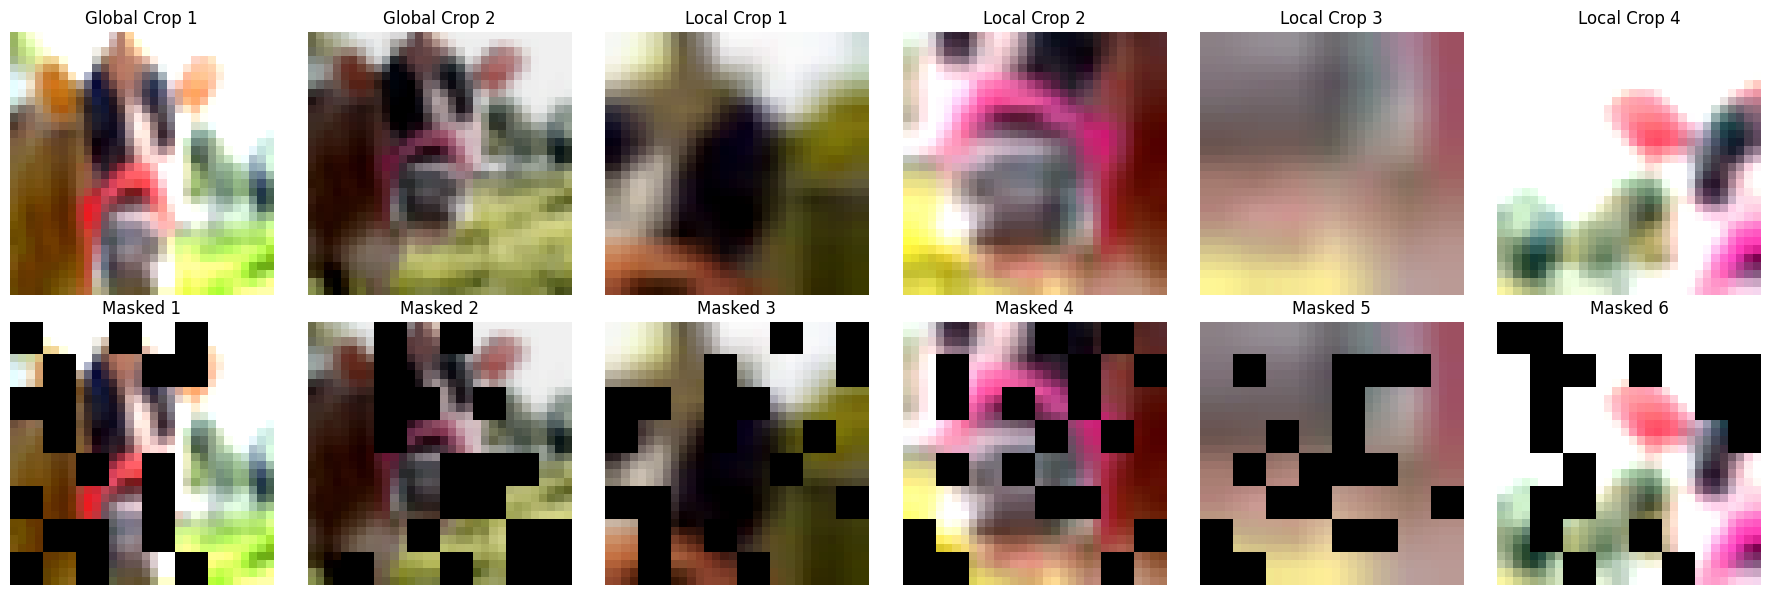

In [6]:

import matplotlib.pyplot as plt
import numpy as np

# Create masked versions of the images
def mask_image(img, mask_ratio=0.3, patch_size=4): # You can play around with these parameters
    """Randomly mask patches of an image"""
    masked_img = img.copy()
    h, w = img.shape[:2]
    
    # Calculate number of patches
    n_patches_h = h // patch_size
    n_patches_w = w // patch_size
    total_patches = n_patches_h * n_patches_w
    
    # Number of patches to mask
    n_mask = int(total_patches * mask_ratio)
    
    # Randomly select patches to mask
    mask_indices = np.random.choice(total_patches, n_mask, replace=False)
    
    for idx in mask_indices:
        patch_row = (idx // n_patches_w) * patch_size
        patch_col = (idx % n_patches_w) * patch_size
        masked_img[patch_row:patch_row+patch_size, patch_col:patch_col+patch_size] = 0
    
    return masked_img

# Create the figure
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
crop_name = ["Global Crop 1","Global Crop 2","Local Crop 1","Local Crop 2","Local Crop 3","Local Crop 4"]

for idx in range(6):
    # Original image in first row
    axes[0, idx].imshow(obs[idx])
    axes[0, idx].axis('off')
    axes[0, idx].set_title(crop_name[idx])
    
    # Masked image in second row
    masked = mask_image(obs[idx], mask_ratio=0.3, patch_size=4)
    axes[1, idx].imshow(masked)
    axes[1, idx].axis('off')
    axes[1, idx].set_title(f'Masked {idx+1}')

plt.tight_layout()
plt.show()

#### Tiny ViT

As we do not have the ressources to train a full ViT-B or -L model, we create our own tiny ViT.

Architecture Overview:
- **Patch Embedding**: Split 32×32 image into 4×4 patches → 64 patches (8×8 grid)
- **CLS Token**: Learnable global token prepended to patch sequence
- **Position Embeddings**: Learnable positions for each patch
- **Transformer Blocks**: Self-attention + MLP layers
- **Projection Heads**: **Separate** projections for CLS and Patch tokens (DINOv2-specific!)

In [ ]:
class PatchEmbed(nn.Module):
    """Split image into patches and embed them"""
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=192):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2  # 64 patches for 32x32 image
        
        # Convolutional layer to create patch embeddings
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
    
    def forward(self, x):
        # x: [B, 3, 32, 32]
        x = self.proj(x)  # [B, embed_dim, 8, 8]
        x = x.flatten(2)  # [B, embed_dim, 64]
        x = x.transpose(1, 2)  # [B, 64, embed_dim]
        return x


class TransformerBlock(nn.Module):
    """Transformer block: Self-Attention + MLP"""
    def __init__(self, embed_dim=192, num_heads=3, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        # Self-attention with residual
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out
        
        # MLP with residual
        x = x + self.mlp(self.norm2(x))
        return x


class TinyViT(nn.Module):
    """Tiny Vision Transformer for CIFAR-100 with iBOT masking support"""
    def __init__(self, img_size=32, patch_size=4, in_channels=3, 
                 embed_dim=192, depth=6, num_heads=3, mlp_ratio=4.0, 
                 dropout=0.0, out_dim=256):
        super().__init__()
        
        # Patch embedding
        self.patch_embed = PatchEmbed(img_size, patch_size, in_channels, embed_dim)
        n_patches = self.patch_embed.n_patches
        
        # CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        
        # Position embeddings (CLS + patches)
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)
        
        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)
        
        # One joint projection head as data is very low dim
        self.head = nn.Linear(embed_dim, out_dim)
        
        # Initialize weights
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
    
    def forward(self, x, mask=None, mask_token=None):
        """
        Args:
            x: Input images [B, 3, 32, 32]
            mask: Optional boolean mask [B, n_patches] indicating which patches to mask
            mask_token: Optional learnable mask token [1, embed_dim] to replace masked patches
        Returns:
            cls_out: CLS token features [B, out_dim]
            patch_out: Patch token features [B, n_patches, out_dim]
        """
        B = x.shape[0]
        
        # Get patch embeddings
        x = self.patch_embed(x)  # [B, n_patches, embed_dim]
        

        # Applz iBOT masking
        
        if mask is not None and mask_token is not None:    
            # Expand mask token to match batch size
            mask_token = mask_token.to(x.dtype)
            mask_token_expanded = mask_token.expand(B, -1)  # [B, embed_dim]
            
            # Apply mask - replace patches where mask is True
            for i in range(B):
                # Get indices where mask is True for this sample
                masked_indices = mask[i].nonzero(as_tuple=True)[0]
                # Replace those patches with mask token
                x[i, masked_indices] = mask_token_expanded[i:i+1]
        
        # Add CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)  # [B, 1, embed_dim]
        x = torch.cat([cls_tokens, x], dim=1)  # [B, n_patches+1, embed_dim]
        
        # Add positional embeddings
        x = x + self.pos_embed
        x = self.pos_drop(x)
        
        # Pass through transformer blocks
        for block in self.blocks:
            x = block(x)
        
        x = self.norm(x)
        
        # Split CLS and patch tokens
        cls_token = x[:, 0]  # [B, embed_dim]
        patch_tokens = x[:, 1:]  # [B, n_patches, embed_dim]
        
        # Project to output space
        # We use a joint head here as the data is too simple for two heads -> training too unstable
        cls_out = self.head(cls_token)
        patch_out = self.head(patch_tokens)
        
        
        return cls_out, patch_out

<a name="task5.1"></a>
### Task 5.1: DINOv2 Student-Teacher Model

Training with raw image reconstruction or contrastive pairs requires explicit supervision or negative samples. The student-teacher architecture solves this elegantly: the teacher (a slowly updating copy of the student) provides stable, high-quality targets, while the student learns to match them. This self-distillation creates a learning signal without any labels, and the exponential moving average (EMA) prevents the model from collapsing to trivial solutions.

**Architecture**:
- **Student**: Regular model, trained with gradients
- **Teacher**: EMA of student, provides targets (no gradients)
- **Centering**: Running mean of teacher CLS outputs only (patch tokens NOT centered)

**Loss Components**

Total Loss: `L_total = L_DINO + λ_iBOT × L_iBOT + λ_KoLeo × L_KoLeo`

1. DINO Loss (Image-Level Self-Distillation)
Cross-entropy between student and teacher CLS token outputs across multiple crops. The student learns to match the teacher's global image representation across different augmented views, encouraging consistent representations (similar to BYOL, but without the predictor network and using a different collapse-prevention mechanism).

2. iBOT Loss (Masked Image Modeling)
Masks 30% (default) of patches and forces the student to predict teacher features at masked locations. Encourages complete scene understanding without pixel-level reconstruction.

3. KoLeo Regularization (Uniformity)
Encourages uniform distribution of features on the hypersphere, preventing feature collapse. Acts as a "spreading force" to maintain diverse, discriminative representations (Not discussed before as it is only added for stability).


**TODO**: Implement the DINO Loss for CLS tokens.

In [ ]:
class DINOv2:
    """DINOv2 framework with iBOT and KoLeo regularization"""
    def __init__(self, model_config=None, teacher_temp=0.07, student_temp=0.1, 
                 momentum=0.996, center_momentum=0.9, ibot_weight=1.0, 
                 koleo_weight=0.1, ibot_mask_ratio=0.3):
        
        # Default tiny ViT config
        if model_config is None:
            model_config={
            'img_size': 32,
            'patch_size': 4,
            'embed_dim': 192,
            'depth': 6,
            'num_heads': 3,
            'out_dim': 4096,
        }
        
        self.student = TinyViT(**model_config).to(device)
        self.teacher = TinyViT(**model_config).to(device)
        
        # Initialize teacher with student weights
        self.teacher.load_state_dict(self.student.state_dict())
        
        # Teacher doesn't need gradients
        for p in self.teacher.parameters():
            p.requires_grad = False
            
        self.teacher.eval()
        
        # IMPORTANT: Learnable mask token for iBOT
        # This will replace masked patches in the student input
        self.mask_token = nn.Parameter(
            torch.zeros(1, model_config['embed_dim'], device=device)
        )
        nn.init.normal_(self.mask_token, std=0.02)
        
        # Temperature warmup (DINOv2 uses slightly higher initial temp)
        self.teacher_temp_schedule = np.concatenate((
            np.linspace(0.04, teacher_temp, 30),  # Warmup for 30 iterations
            np.ones(1000) * teacher_temp  # Then constant
        ))
        self.teacher_temp = teacher_temp
        self.student_temp = student_temp
        self.momentum = momentum
        
        # DINOv2: Only center CLS tokens, not patch tokens
        self.center_cls = torch.zeros(1, model_config['out_dim']).to(device)
        self.center_momentum = center_momentum
        self.center_initialized = False
        
        # iBOT (masked image modeling) parameters
        self.ibot_weight = ibot_weight
        self.ibot_mask_ratio = ibot_mask_ratio
        self.num_patches = (model_config['img_size'] // model_config['patch_size']) ** 2
        self.patch_size = model_config['patch_size']
        self.img_size = model_config['img_size']
        
        # KoLeo regularization weight
        self.koleo_weight = koleo_weight
        
        self.iteration = 0
    
    @torch.no_grad()
    def update_teacher(self):
        """EMA update of teacher weights"""
        for param_s, param_t in zip(self.student.parameters(), self.teacher.parameters()):
            param_t.data.mul_(self.momentum).add_(param_s.data, alpha=1 - self.momentum)
    
    @torch.no_grad()
    def update_center(self, teacher_cls):
        """Update center for teacher CLS outputs only (DINOv2 change)"""
        # First batch: initialize center with actual values
        if not self.center_initialized:
            self.center_cls = teacher_cls.mean(dim=0, keepdim=True)
            self.center_initialized = True
            return
        
        # EMA update
        cls_center = teacher_cls.mean(dim=0, keepdim=True)
        self.center_cls = self.center_cls * self.center_momentum + cls_center * (1 - self.center_momentum)
    
    def generate_mask(self, batch_size):
        """Generate random mask for iBOT (masked image modeling)"""
        num_masked = int(self.ibot_mask_ratio * self.num_patches)
        mask = torch.zeros(batch_size, self.num_patches, dtype=torch.bool, device=device)
        
        for i in range(batch_size):
            # Random masking for each sample
            masked_indices = torch.randperm(self.num_patches)[:num_masked]
            mask[i, masked_indices] = True
        
        return mask
    
    def apply_mask_to_input(self, x, mask):
        """
        Apply mask directly to the input by replacing masked patches with mask token.
        This happens BEFORE the patches are embedded by the model.
        
        Args:
            x: Input images [B, 3, H, W]
            mask: Boolean mask [B, num_patches] indicating which patches to mask
        
        Returns:
            Masked input that can be passed to the model with mask information
        """
        # Note: The actual masking needs to be done inside the ViT's patch embedding
        # Since we don't modify TinyViT here, we return both x and mask
        # and TinyViT.forward() should accept mask parameter
        return x, mask

    def dino_loss(self, student_output, teacher_output):
        """Stable cross-entropy for DINO"""
        student_out = F.log_softmax(student_output, dim=-1)
        teacher_out = F.softmax(teacher_output, dim=-1)
        return -(teacher_out * student_out).sum(dim=-1).mean()

    def koleo_loss(self, features, eps=1e-8):
        """Official KoLeo: uses nearest neighbor distances only"""
        features = F.normalize(features, dim=-1, p=2)
        
        # Find nearest neighbor for each sample
        dots = torch.mm(features, features.t())
        n = features.shape[0]
        dots.view(-1)[:: (n + 1)].fill_(-1)  # Fill diagonal with -1
        
        # Get nearest neighbor index
        _, nn_idx = torch.max(dots, dim=1)
        
        # Compute L2 distance to nearest neighbor
        nn_features = features[nn_idx]
        distances = (features - nn_features).norm(dim=-1, p=2)
        
        # KoLeo loss: negative log of distances
        loss = -torch.log(distances + eps).mean()
        
        return loss
    
    def forward(self, crops):
        """
        Args:
            crops: List of image crops [B, 3, H, W]
        Returns:
            loss: DINOv2 loss (DINO + iBOT + KoLeo)
            metrics: Dictionary of metrics for analysis
        """
        n_global = 2
        batch_size = crops[0].shape[0]
        
        # Get current teacher temperature (with warmup)
        current_temp = self.teacher_temp_schedule[min(self.iteration, len(self.teacher_temp_schedule) - 1)]
        
        # Generate masks for iBOT
        ibot_masks = None
        if self.ibot_weight > 0:
            ibot_masks = [self.generate_mask(batch_size) for _ in range(n_global)]
        
        # Student forward pass 
        student_cls = []
        student_patch = []
        
        for idx, crop in enumerate(crops):
            if idx < n_global and ibot_masks is not None:
                # Global crops: student sees masked version
                cls_out, patch_out = self.student(crop, mask=ibot_masks[idx], mask_token=self.mask_token)
            else:
                # Local crops: unmasked
                cls_out, patch_out = self.student(crop)
            
            student_cls.append(cls_out)
            student_patch.append(patch_out)
        
        # Teacher forward pass 
        with torch.no_grad():
            teacher_cls = []
            teacher_patch = []
            
            for crop in crops[:n_global]:
                cls_out, patch_out = self.teacher(crop)
                teacher_cls.append(cls_out)
                teacher_patch.append(patch_out)
            
            # Update center (only CLS tokens in DINOv2)
            # We do not use mean centering here as it is too unstable for such small batch size
            # self.update_center(torch.cat(teacher_cls, dim=0))
        
        # DINO CLS Loss (standard self-distillation)
        loss_cls = 0
        n_loss_terms = 0
        
        for i, s_cls in enumerate(student_cls):
            # Student temperature scaling
            s_cls_scaled = s_cls / self.student_temp
            
            for j, t_cls in enumerate(teacher_cls):
                # Skip self-comparison for global crops
                if i < n_global and i == j:
                    continue
                
                # Teacher: centering + temperature scaling
                # We do not use mean centering here as it is too unstable for such small batch size
                #t_cls_scaled = (t_cls - self.center_cls) / current_temp 
                t_cls_scaled = (t_cls) / current_temp
                
                loss_cls += self.dino_loss(s_cls_scaled, t_cls_scaled)
                n_loss_terms += 1
        
        loss_cls /= n_loss_terms
        
        # iBOT Loss (masked patch prediction, cross-view)
        loss_ibot = 0
        n_ibot_terms = 0
        
        if self.ibot_weight > 0 and ibot_masks is not None:
            # Cross-view masked prediction:
            # Student's masked patches from crop i should match teacher's patches from crop j 
            for i in range(n_global):
                for j in range(n_global):
                    if i == j:
                        continue  
                    
                    # Get mask for student crop i
                    mask = ibot_masks[i]  # [B, num_patches]
                    
                    # Student: masked predictions from crop i
                    student_masked = student_patch[i][mask]  # [num_masked_total, out_dim]
                    student_masked = student_masked / self.student_temp
                    
                    # Teacher: unmasked patches from crop j at same positions
                    teacher_target = teacher_patch[j][mask]  # [num_masked_total, out_dim]
                    teacher_target = teacher_target / current_temp  # No centering for patches
                    
                    loss_ibot += self.dino_loss(student_masked, teacher_target)
                    n_ibot_terms += 1
            
            loss_ibot /= n_ibot_terms
        
        # KoLeo Regularization
        loss_koleo = 0
        if self.koleo_weight > 0:
            # Apply KoLeo to student CLS tokens from global crops
            # Use raw features before temperature scaling
            global_cls_features = torch.cat(student_cls[:n_global], dim=0)
            loss_koleo = self.koleo_loss(global_cls_features)
        
        # Total Loss
        total_loss = loss_cls + self.ibot_weight * loss_ibot + self.koleo_weight * loss_koleo
        
        if torch.isnan(total_loss):
            print(f"NaN detected at iteration {self.iteration}!")
            raise ValueError("NaN loss detected")
        
        # Update teacher
        with torch.no_grad():
            self.update_teacher()
        
        self.iteration += 1
        
        # Metrics
        with torch.no_grad():
            metrics = {
                'loss_cls': loss_cls.item(),
                'loss_ibot': (self.ibot_weight * loss_ibot).item() if isinstance(loss_ibot, torch.Tensor) else self.ibot_weight * loss_ibot,
                'loss_koleo': (self.koleo_weight * loss_koleo).item() if isinstance(loss_koleo, torch.Tensor) else self.koleo_weight * loss_koleo,
                'total_loss': total_loss.item(),
                'std_cls': torch.cat(student_cls[:n_global], dim=0).std().item(),
                'std_patch': torch.cat([s.flatten(0, 1) for s in student_patch[:n_global]], dim=0).std().item(),
                'teacher_temp': current_temp,
            }
                
        return total_loss, metrics


# Initialize DINOv2 model
dino_v2 = DINOv2(
    student_temp=0.1,   # Keep moderate
    teacher_temp=0.07,  
    
    koleo_weight=0.5,   
    ibot_weight=0.5,    
    ibot_mask_ratio=0.3,
    
    momentum=0.998,   
    center_momentum=0.5, # We do not use mean centering here as it is too unstable for such small batch size
)

<a name="task5.2"></a>
### Task 5.2: Training Loop with Convergence Tracking

We'll track:
- **Loss convergence** for CLS and Patch tokens separately
- **Standard deviation** of features (diversity)
- **Rate of convergence** (which token type learns faster?)

Expected runtime: ~20 minutes for 10 epochs on GPU.

You can play around with the HPs (lr, epochs, loss weighting terms, masking ratio etc.) to see how the downstream analysis results change. Also observe how unstable the DINOv2 training can be.

**TODO**: Train a stable DINO model. Play around with the HPs if you want and observe how the subsequent quantitative and visual PCA analysis change.

In [17]:
# Training setup
params = list(dino_v2.student.parameters()) + [dino_v2.mask_token]
optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=0.04)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Training history for analysis
history = {
    'loss_cls': [],
    'loss_ibot': [],
    'loss_koleo': [],
    'total_loss': [],
    'std_cls': [],
    'std_patch': [],
    'teacher_temp': [],
}

# Optimizations
torch.backends.cudnn.benchmark = True
scaler = torch.amp.GradScaler('cuda')  # Mixed precision

num_epochs = 10 
log_interval = 50

print("Starting DINOv2 training...")
print(f"iBOT weight: {dino_v2.ibot_weight}, KoLeo weight: {dino_v2.koleo_weight}")
print(f"Mask ratio: {dino_v2.ibot_mask_ratio}\n")

dino_v2.student.train()

for epoch in range(num_epochs):
    epoch_metrics = {k: [] for k in history.keys()}
    
    for batch_idx, crops in enumerate(train_loader):
        # Move crops to device (non_blocking for async transfer)
        crops = [crop.to(device, non_blocking=True) for crop in crops]
        
        # Forward pass with mixed precision
        with torch.amp.autocast('cuda'):
            loss, metrics = dino_v2.forward(crops)
        
        # Backward pass with gradient scaling
        optimizer.zero_grad(set_to_none=True)  # Faster than zero_grad()
        scaler.scale(loss).backward()
        
        # Gradient clipping (unscale first for proper clipping)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(dino_v2.student.parameters(), 3.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        # Log metrics
        for k, v in metrics.items():
            if k in epoch_metrics:
                epoch_metrics[k].append(v)
        
        if batch_idx % log_interval == 0:
            print(f"Epoch {epoch+1}/{num_epochs} [{batch_idx}/{len(train_loader)}] "
                  f"Total: {metrics['total_loss']:.4f} | "
                  f"DINO cls: {metrics['loss_cls']:.4f} | "
                  f"iBOT: {metrics['loss_ibot']:.4f} | "
                  f"KoLeo: {metrics['loss_koleo']:.4f}")
    
    # Store epoch averages
    for k in history.keys():
        if epoch_metrics[k]:
            history[k].append(np.mean(epoch_metrics[k]))
    
    scheduler.step()
    
    print(f"\n{'='*80}")
    print(f"Epoch {epoch+1} Summary:")
    print(f"  Total Loss: {history['total_loss'][-1]:.4f}")
    print(f"  DINO CLS Loss: {history['loss_cls'][-1]:.4f}")
    print(f"  iBOT Loss: {history['loss_ibot'][-1]:.4f}")
    print(f"  KoLeo Loss: {history['loss_koleo'][-1]:.4f}")
    print(f"  Feature Std - CLS: {history['std_cls'][-1]:.4f}, Patch: {history['std_patch'][-1]:.4f}")
    print(f"  Teacher Temp: {history['teacher_temp'][-1]:.4f}")
    print(f"{'='*80}\n")

Starting DINOv2 training...
iBOT weight: 0.5, KoLeo weight: 0.5
Mask ratio: 0.3

Epoch 1/10 [0/391] Total: 15.6726 | DINO cls: 8.7269 | iBOT: 6.2800 | KoLeo: 0.6658
Epoch 1/10 [50/391] Total: 5.8594 | DINO cls: 3.0413 | iBOT: 2.1062 | KoLeo: 0.7119
Epoch 1/10 [100/391] Total: 5.2595 | DINO cls: 2.8333 | iBOT: 1.9712 | KoLeo: 0.4550
Epoch 1/10 [150/391] Total: 4.8260 | DINO cls: 2.7131 | iBOT: 1.8107 | KoLeo: 0.3022
Epoch 1/10 [200/391] Total: 4.5089 | DINO cls: 2.5889 | iBOT: 1.6976 | KoLeo: 0.2224
Epoch 1/10 [250/391] Total: 4.2788 | DINO cls: 2.4525 | iBOT: 1.6851 | KoLeo: 0.1413
Epoch 1/10 [300/391] Total: 4.0399 | DINO cls: 2.3458 | iBOT: 1.5930 | KoLeo: 0.1011
Epoch 1/10 [350/391] Total: 4.0285 | DINO cls: 2.3970 | iBOT: 1.5597 | KoLeo: 0.0718

Epoch 1 Summary:
  Total Loss: 4.9722
  DINO CLS Loss: 2.7839
  iBOT Loss: 1.8778
  KoLeo Loss: 0.3105
  Feature Std - CLS: 0.2571, Patch: 0.3320
  Teacher Temp: 0.0688

Epoch 2/10 [0/391] Total: 3.8048 | DINO cls: 2.2356 | iBOT: 1.5156 | K

<a name="task5.3"></a>
### Task 5.3: CLS vs Patch Token Convergence

By plotting the learning curves side-by-side, we can visually identify which token type converges faster, which is more stable, and how their behaviors differ. This visual analysis is crucial for building intuition about how different architectural components learn in foundation models.

**TODO**: Analyze the differences between CLS and Patch tokens:

1. Which token type converges faster?
2. Which is more stable during training?
3. How does feature diversity (std) evolve?
4. What does this tell us about global vs local learning?

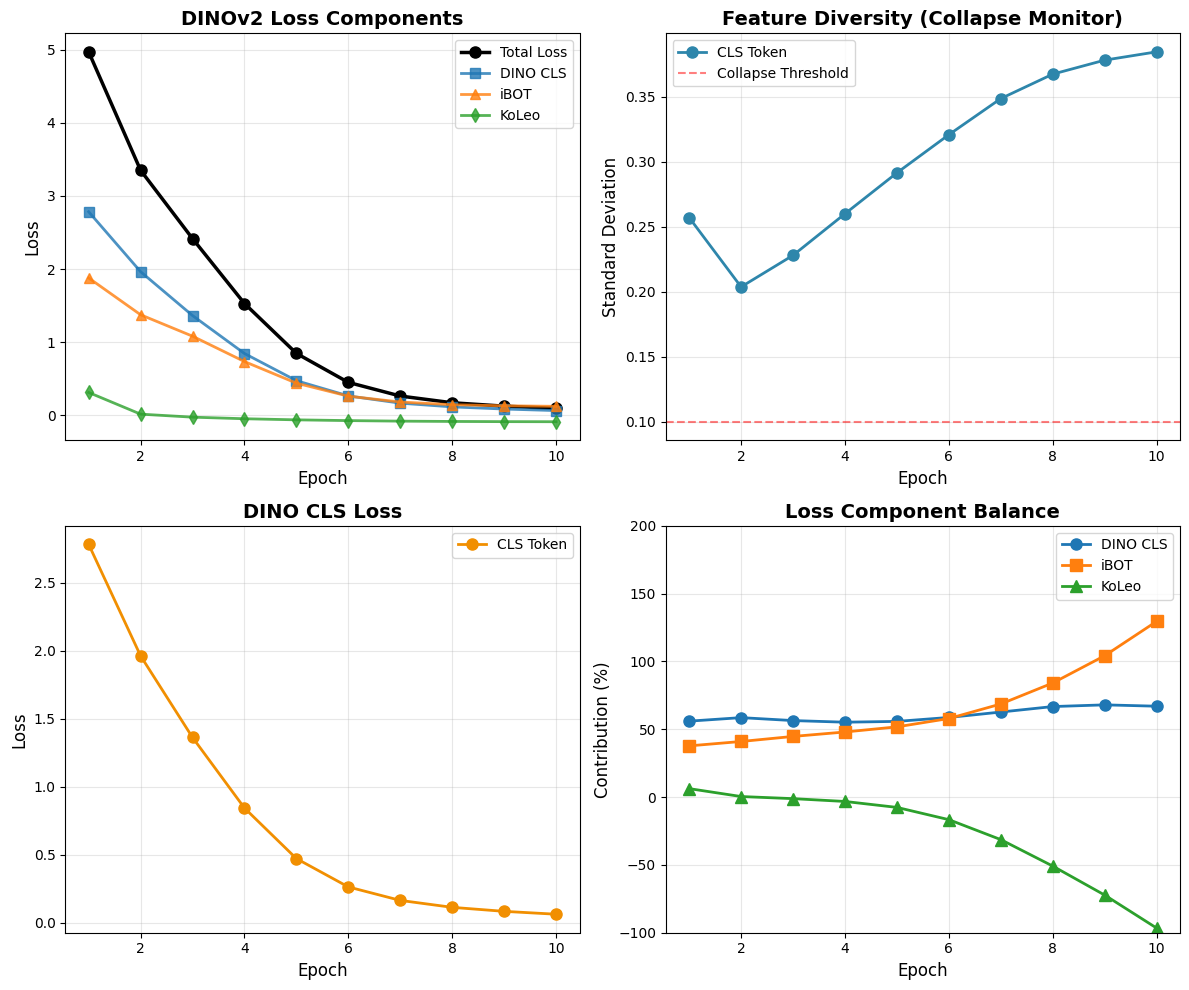

In [22]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
epochs = range(1, num_epochs + 1)

# 1. Total Loss and Main Components
axes[0, 0].plot(epochs, history['total_loss'], 'o-', label='Total Loss', linewidth=2.5, markersize=8, color='black')
axes[0, 0].plot(epochs, history['loss_cls'], 's-', label='DINO CLS', linewidth=2, markersize=7, alpha=0.8)
axes[0, 0].plot(epochs, history['loss_ibot'], '^-', label='iBOT', linewidth=2, markersize=7, alpha=0.8)
axes[0, 0].plot(epochs, history['loss_koleo'], 'd-', label='KoLeo', linewidth=2, markersize=7, alpha=0.8)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('DINOv2 Loss Components', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. Feature Diversity (Standard Deviation)
axes[0, 1].plot(epochs, history['std_cls'], 'o-', label='CLS Token', linewidth=2, markersize=8, color='#2E86AB')
axes[0, 1].axhline(y=0.1, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Collapse Threshold')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Standard Deviation', fontsize=12)
axes[0, 1].set_title('Feature Diversity (Collapse Monitor)', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# 3. DINO CLS
axes[1, 0].plot(epochs, history['loss_cls'], 'o-', label='CLS Token', linewidth=2, markersize=8, color='#F18F01')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Loss', fontsize=12)
axes[1, 0].set_title('DINO CLS Loss', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# 4. Loss Component Contribution (Percentage)
total_losses = np.array(history['total_loss'])
dino_contribution = (np.array(history['loss_cls']) / total_losses) * 100
ibot_contribution = (np.array(history['loss_ibot']) / total_losses) * 100
koleo_contribution = (np.array(history['loss_koleo']) / total_losses) * 100

axes[1, 1].plot(epochs, dino_contribution, 'o-', label='DINO CLS', linewidth=2, markersize=8)
axes[1, 1].plot(epochs, ibot_contribution, 's-', label='iBOT', linewidth=2, markersize=8)
axes[1, 1].plot(epochs, koleo_contribution, '^-', label='KoLeo', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Contribution (%)', fontsize=12)
axes[1, 1].set_title('Loss Component Balance', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([-100, 200])

plt.tight_layout()
plt.show()

**Comment**: The iBOT contribution grows over time while KoLeo becomes increasingly negative. This is expected behavior: as features spread out on the hypersphere (std increasing from 0.2 to 0.45), nearest-neighbor distances exceed 1.0, making the KoLeo loss negative. The negative KoLeo indicates well-spread features, which is the goal of this regularizer.

**Answers**

Loss Components

Both DINO CLS and iBOT decrease smoothly together, indicating balanced training. KoLeo going negative is healthy, it means features are well-spread with distances > 1 on the unit hypersphere.

Feature Diversity

CLS token std increases from 0.2 to 0.45, well above the 0.1 collapse threshold. The steady increase shows the model is learning increasingly diverse representations rather than collapsing. This confirms the fixes (removing centering, shared head) resolved the instability.

DINO CLS Loss

Smooth convergence from 2.8 to ~0.1.

Loss Balance

The percentage plot shows iBOT contribution growing over time (reaching >100% due to KoLeo going negative). This is acceptable, iBOT handles fine-grained patch prediction while DINO CLS maintains global consistency. Both losses converging near zero indicates the student successfully matches the teacher at both levels.



<a name="task5.4"></a>
### Task 5.4: PCA Analysis of Patch Tokens
Beyond training metrics, we want to see what the model actually learned. By applying PCA to the patch tokens, we can visualize the dominant visual concepts captured by the model. Each principal component highlights different semantic aspects (e.g., object boundaries, textures, colors, or spatial structures). The RGB overlay combines the first three components, where each color channel represents one principal component, revealing how the model decomposes scenes into interpretable visual patterns.

**TODO**: Visualize what the model has learned through PCA of patch token representations. What visual concepts do the principal components capture? Do they correspond to semantically meaningful features like object parts, boundaries, or textures?

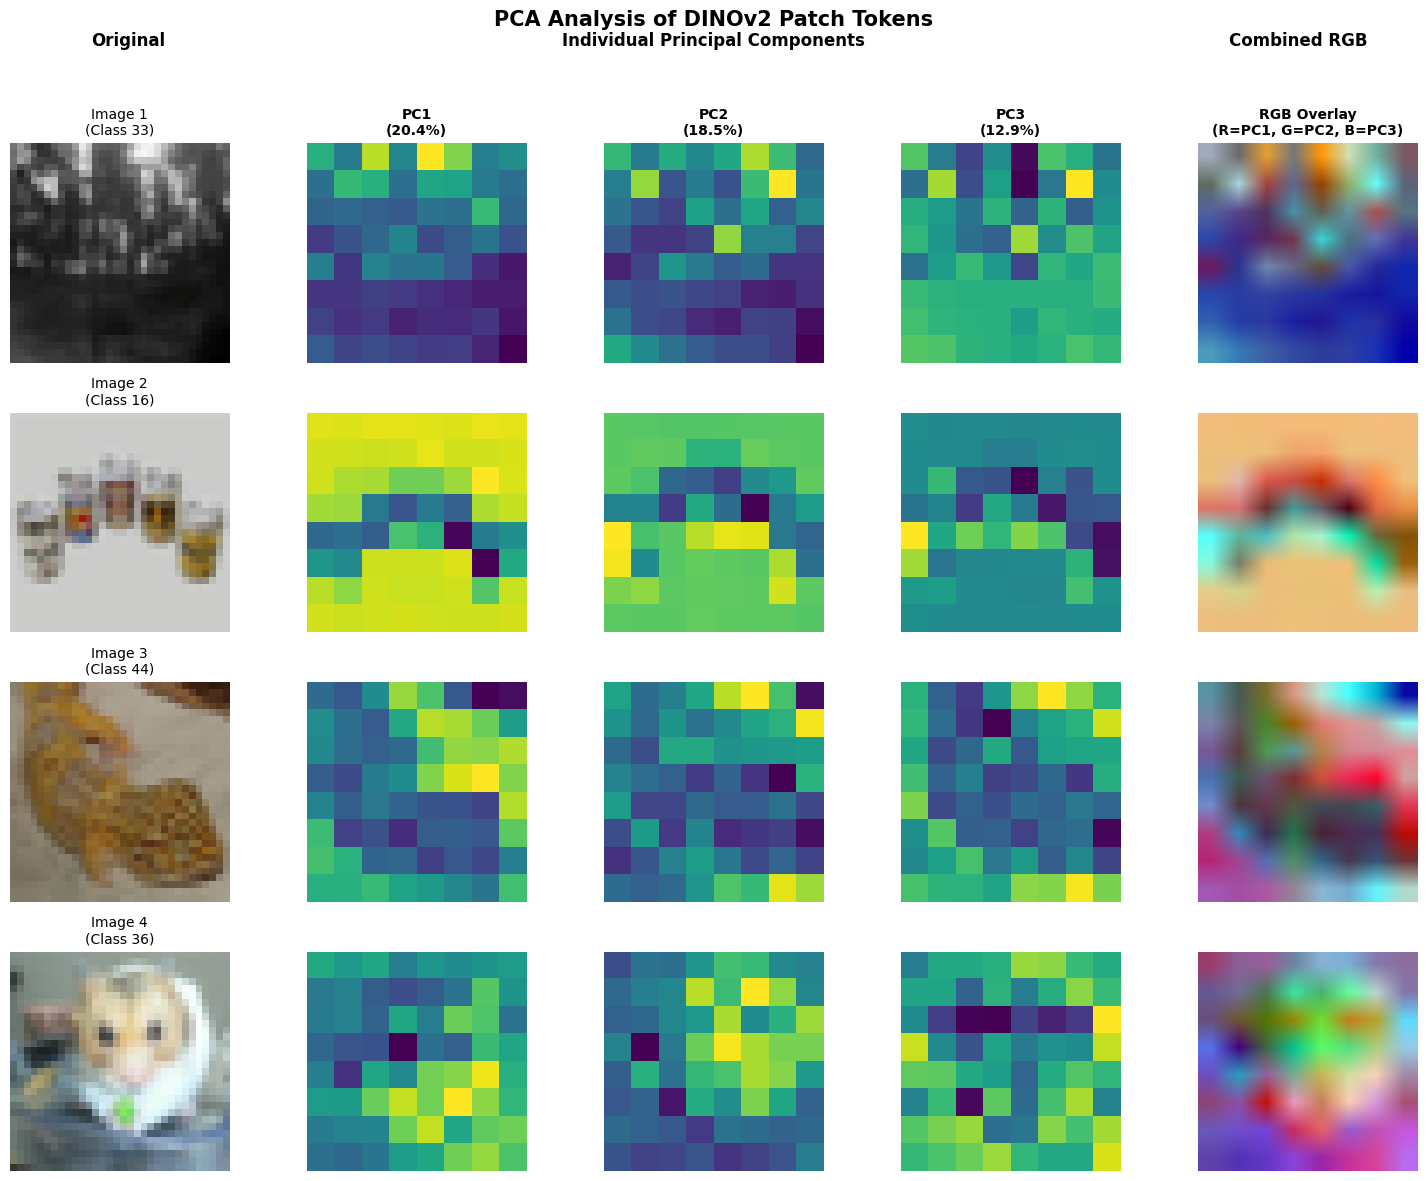

In [25]:
# Get some test images
test_dataset = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
    ])
)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

# Get a batch and compute patch tokens
dino_v2.student.eval()

with torch.no_grad():
    images, labels = next(iter(test_loader))
    images = images.to(device)
    
    # Get patch tokens from student
    _, patch_tokens = dino_v2.student(images)
    # patch_tokens shape: [batch_size, num_patches, embed_dim]
    
# Prepare data for PCA
batch_size, num_patches, embed_dim = patch_tokens.shape
patch_size = int(np.sqrt(num_patches))  # Assuming square patches

# Reshape for PCA: combine all patches from all images
all_patches = patch_tokens.reshape(-1, embed_dim).cpu().numpy()

# Perform PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(all_patches)

# Reshape back to spatial structure
pca_spatial = pca_result.reshape(batch_size, patch_size, patch_size, 3)

# Visualization
fig, axes = plt.subplots(4, 5, figsize=(15, 12))

num_images = min(4, batch_size)

for i in range(num_images):
    # Original image
    img = images[i].cpu().numpy()
    img = np.transpose(img, (1, 2, 0))
    img = img * np.array([0.2675, 0.2565, 0.2761]) + np.array([0.5071, 0.4867, 0.4408])
    img = np.clip(img, 0, 1)
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Image {i+1}\n(Class {labels[i].item()})', fontsize=10)
    axes[i, 0].axis('off')
    
    # Individual PCA components as heatmaps
    for comp_idx in range(3):
        component_map = pca_spatial[i, :, :, comp_idx]
        
        # Normalize to [0, 1] for visualization
        comp_min, comp_max = component_map.min(), component_map.max()
        if comp_max - comp_min > 1e-6:
            component_map_norm = (component_map - comp_min) / (comp_max - comp_min)
        else:
            component_map_norm = component_map
        
        # Show as heatmap
        im = axes[i, 1 + comp_idx].imshow(component_map_norm, cmap='viridis', interpolation='nearest')
        if i == 0:
            axes[i, 1 + comp_idx].set_title(f'PC{comp_idx+1}\n({pca.explained_variance_ratio_[comp_idx]*100:.1f}%)', 
                                           fontsize=10, fontweight='bold')
        axes[i, 1 + comp_idx].axis('off')
    
    # RGB overlay: PC1=Red, PC2=Green, PC3=Blue
    rgb_overlay = np.zeros((patch_size, patch_size, 3))
    for comp_idx in range(3):
        component_map = pca_spatial[i, :, :, comp_idx]
        # Normalize each component to [0, 1]
        comp_min, comp_max = component_map.min(), component_map.max()
        if comp_max - comp_min > 1e-6:
            rgb_overlay[:, :, comp_idx] = (component_map - comp_min) / (comp_max - comp_min)
        else:
            rgb_overlay[:, :, comp_idx] = component_map
    
    axes[i, 4].imshow(rgb_overlay, interpolation='bilinear')
    if i == 0:
        axes[i, 4].set_title('RGB Overlay\n(R=PC1, G=PC2, B=PC3)', fontsize=10, fontweight='bold')
    axes[i, 4].axis('off')

# Add column labels at the top
fig.text(0.11, 0.95, 'Original', ha='center', fontsize=12, fontweight='bold')
fig.text(0.5, 0.95, 'Individual Principal Components', ha='center', fontsize=12, fontweight='bold')
fig.text(0.89, 0.95, 'Combined RGB', ha='center', fontsize=12, fontweight='bold')

fig.suptitle('PCA Analysis of DINOv2 Patch Tokens', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

**Ground Truth Analysis**

The patch tokens show spatially coherent activations that roughly correspond to semantic regions in the images, where backgrounds, objects, and edges activate different principal components. The RGB overlays demonstrate that DINOv2 learns to segment scenes without any supervision: similar colors indicate patches with similar representations, effectively discovering object boundaries (e.g., the objects vs. background in Image 2, or the hamster's face vs. surroundings in Image 4).